# **Day 2 — Serving the Model with FastAPI**

**What is built:** A FastAPI application that loads the serialized DistilBERT model, tokenizer, and label map from Google Drive, and exposes a */predict* POST endpoint. The app was run in Colab Environment using a background thread for uvicorn and pyngrok to expose a public testing URL , since Colab has no directly accessible local port.

**Input validation:** A Pydantic InputText model validatesincoming requests. Submitting a valid string returns a correct predition as JSON *"Prediction": "Business"*. Submitting invalid input - non-string/missing field - is rejected with a 422 Unprocessable Entity error before reaching the model which prevents scilent corruption of the prediction pipeline.


below you can find a few test cases.

In [ ]:
!pip install fastapi uvicorn pyngrok nest_asyncio --quiet

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3JaOHRPNHuOrUOM9sXXchyaamqa_3RYjpcebXSx7zyoU8RnKg")

In [ ]:
%%writefile main.py
from fastapi import FastAPI
from pydantic import BaseModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import json

app = FastAPI()
final_path = "/content/drive/MyDrive/ag_news_distilbert/final_model"
tokenizer = AutoTokenizer.from_pretrained(final_path)
model = AutoModelForSequenceClassification.from_pretrained(final_path)

with open(f"{final_path}/label_map.json") as f:
  label_map = {int(k): v for k, v in json.load(f).items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

class InputText(BaseModel):
  text: str

@app.post("/predict")
def predict(data: InputText):
  try:
    inputs = tokenizer(data.text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
      outputs = model(**inputs)
      prediction = torch.argmax(outputs.logits, dim=1).item()
    return {"prediction": label_map[prediction]}
  except Exception as e:
    return{"error": str(e)}

Overwriting main.py


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/ag_news_distilbert/"))

['checkpoint-6000', 'checkpoint-12000', 'final_model', 'requirements.txt']


In [ ]:
print(os.listdir("/content/drive/MyDrive/ag_news_distilbert/final_model"))

['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'label_map.json']


In [ ]:
import threading
from pyngrok import ngrok
import uvicorn


def run_server():
  uvicorn.run("main:app", host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server, daemon=True)
thread.start()

import time
time.sleep(3)

public_url = ngrok.connect(8000)
print("Public URL:", public_url)


INFO:     Started server process [8305]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


Public URL: NgrokTunnel: "https://magma-student-pendant.ngrok-free.dev" -> "http://localhost:8000"


## **Verified Test Cases**

"The stock market rallied today after the Federal Reserve announcement." -> correctly predicted "Business", consistent with the model's known behaviour from Day 1 serialization verification.

"12345" -> produced 422 Unprocessable Enitity error.



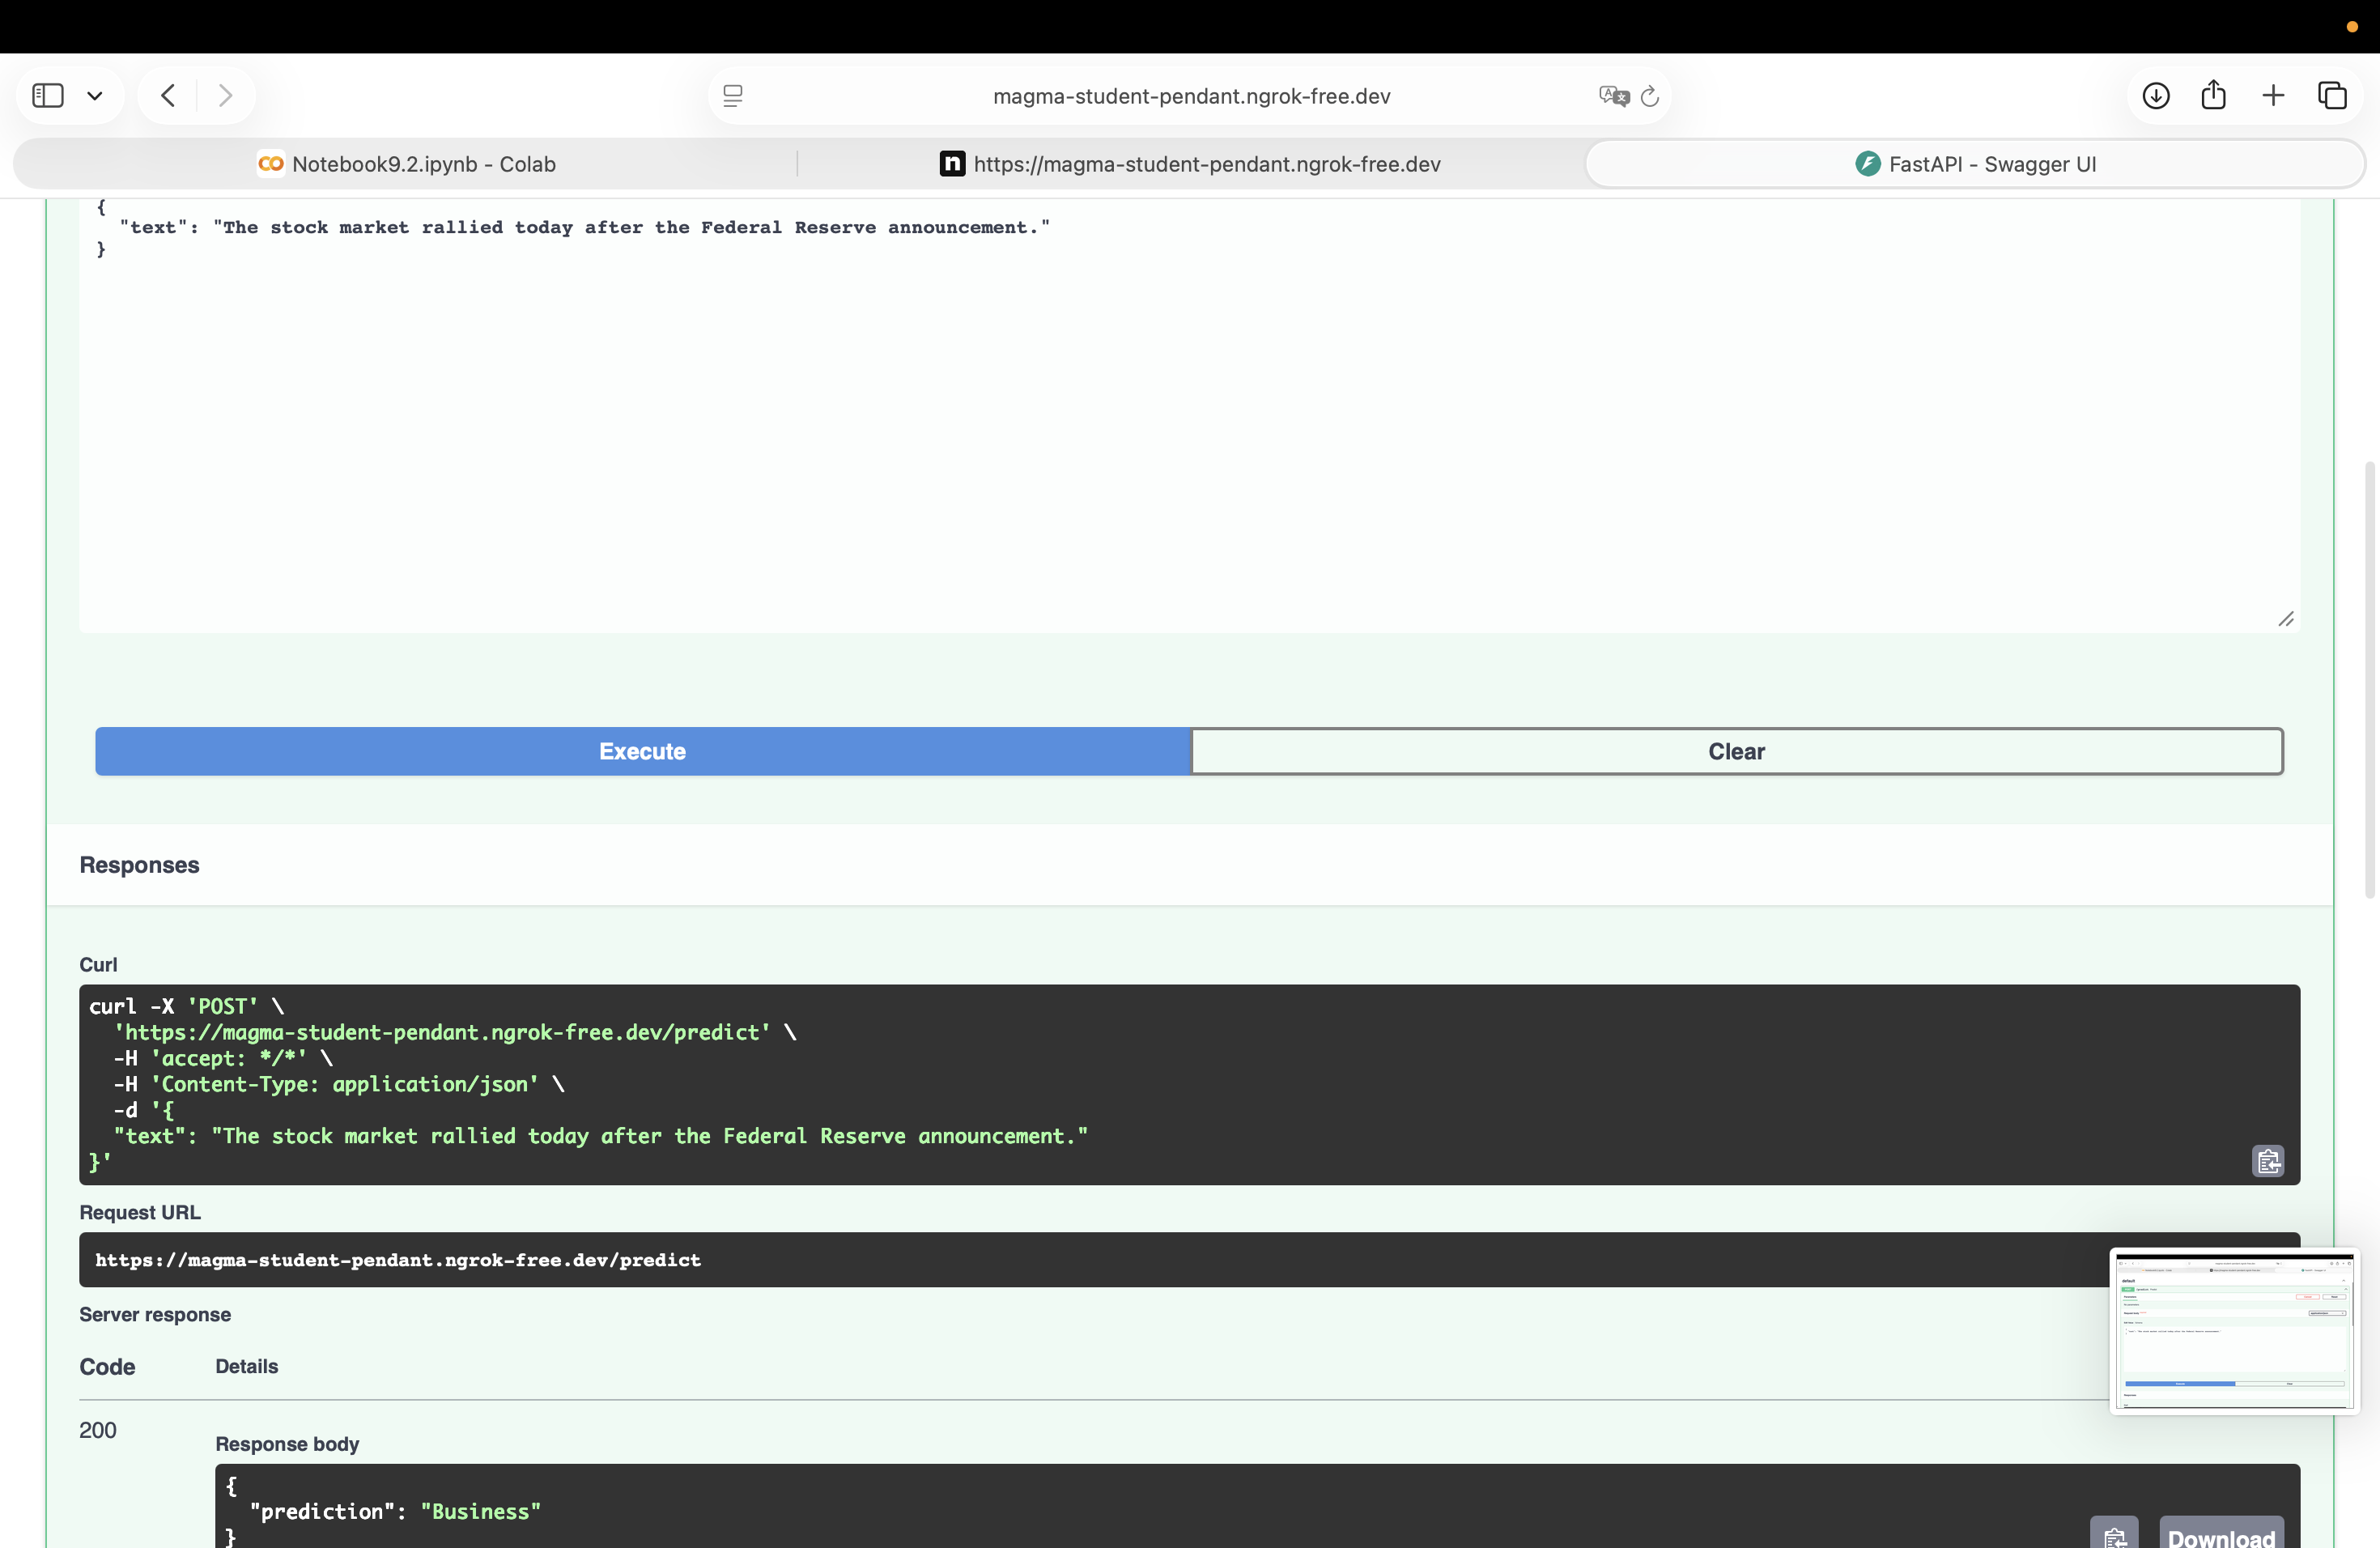![Screenshot 2026-09-20 at 12.46.15.png](
)

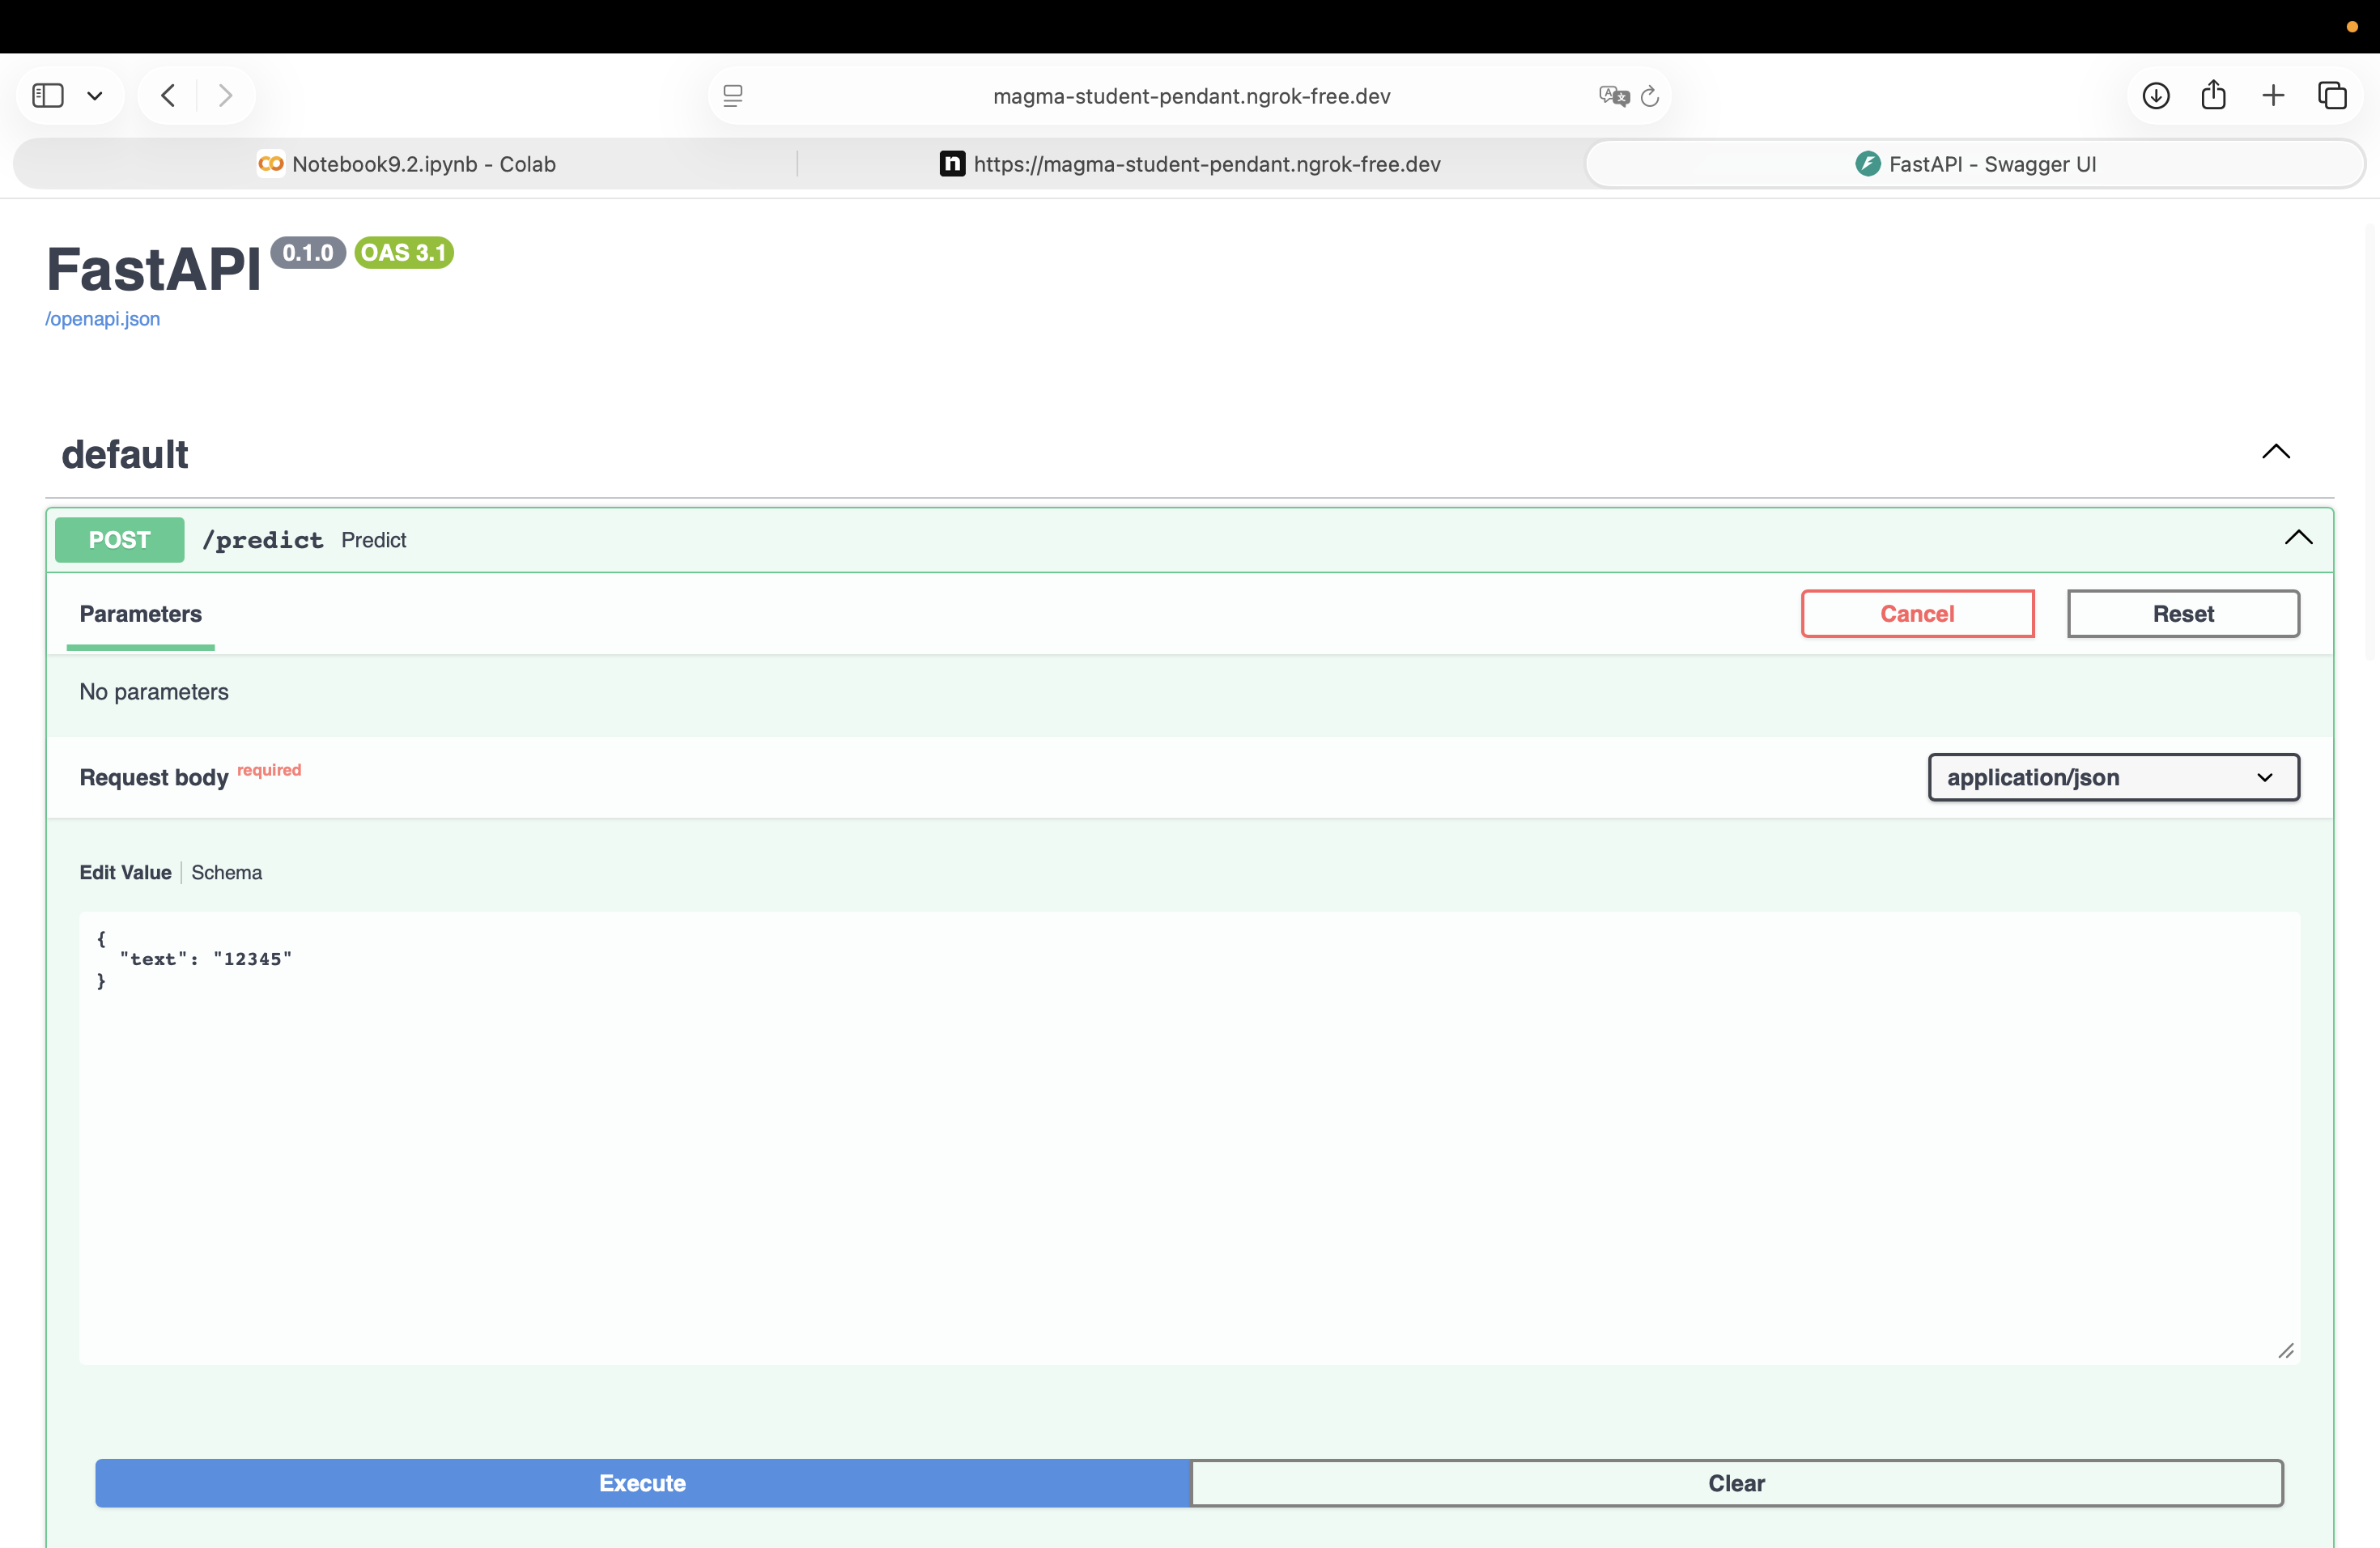

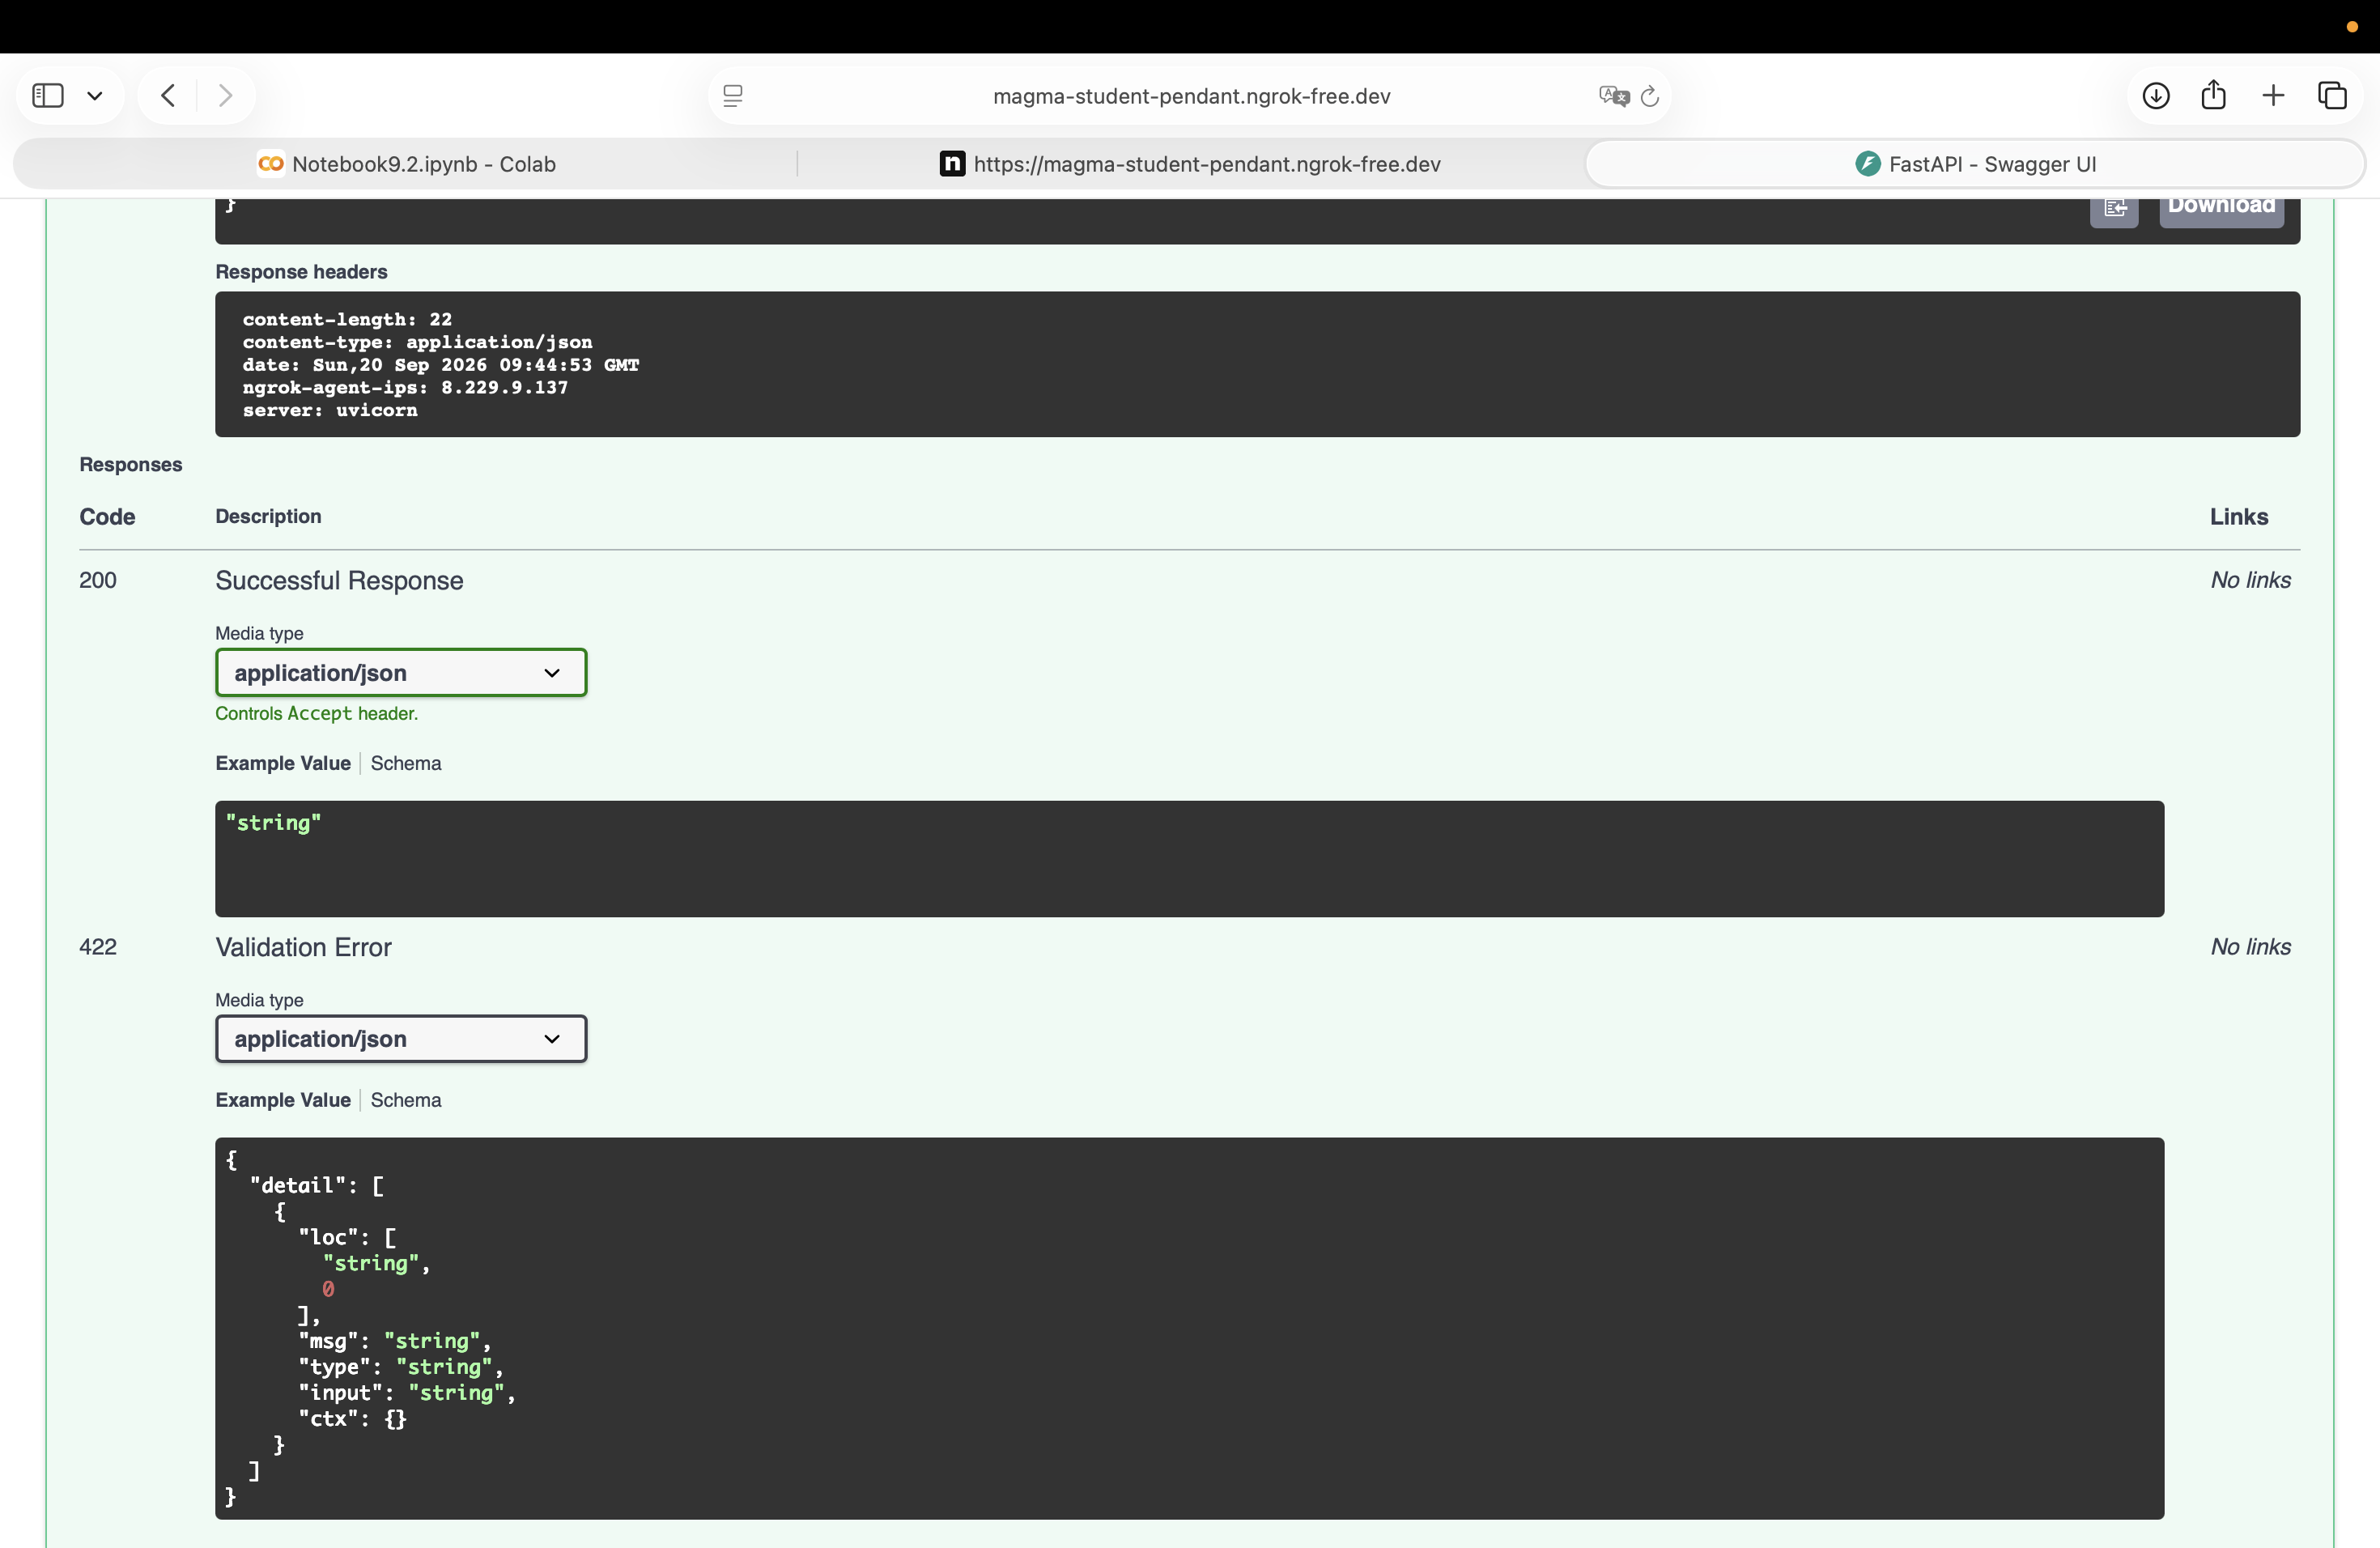